# 📊 Credit Risk Assessment System

## Exploratory Data Analysis (EDA)

---

### 📌 Project Overview

The **Credit Risk Assessment System** is a machine learning project designed to predict whether a borrower is likely to default on a loan based on their financial profile, credit history, and loan-related information.

Financial institutions use credit risk assessment models to minimize losses by identifying high-risk applicants before approving loans.

---

### 🎯 Objectives of this Notebook

The primary objective of this notebook is to perform **Exploratory Data Analysis (EDA)** on the loan default dataset.

In this notebook, we will:

- Load and inspect the dataset
- Understand dataset dimensions and structure
- Explore feature data types
- Analyze missing values and duplicates
- Generate descriptive statistics
- Analyze the target variable
- Perform univariate and bivariate analysis
- Study feature correlations
- Detect outliers
- Summarize key insights for preprocessing

---

### 📂 Dataset

- **Dataset:** Loan Default Prediction Dataset
- **Problem Type:** Binary Classification
- **Target Variable:** Loan Default (0 = No Default, 1 = Default)

---

### 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

---

### 📌 Expected Outcome

By the end of this notebook, we will have a complete understanding of the dataset, enabling us to design an effective preprocessing pipeline and build accurate machine learning models.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

# ============================================
# Visualization Settings
# ============================================

plt.style.use("ggplot")

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 100)

pd.set_option("display.float_format", "{:.2f}".format)

In [4]:
# Load Dataset

df = pd.read_csv("../data/raw/Loan_default.csv")

# Display First Five Records

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [6]:
print(df.columns.tolist())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [5]:
# Dataset Shape

print("=" * 50)
print("Dataset Shape")
print("=" * 50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 255347
Columns : 18


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [8]:
# Display Column Names

df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')

In [9]:
feature_description = pd.DataFrame({
    "Feature": [
        "LoanID",
        "Age",
        "Income",
        "LoanAmount",
        "CreditScore",
        "MonthsEmployed",
        "NumCreditLines",
        "InterestRate",
        "LoanTerm",
        "DTIRatio",
        "Education",
        "EmploymentType",
        "MaritalStatus",
        "HasMortgage",
        "HasDependents",
        "LoanPurpose",
        "HasCoSigner",
        "Default"
    ],
    "Description": [
        "Unique Loan Identifier",
        "Applicant Age",
        "Annual Income",
        "Requested Loan Amount",
        "Credit Score",
        "Employment Duration (Months)",
        "Number of Existing Credit Lines",
        "Interest Rate",
        "Loan Repayment Duration",
        "Debt-to-Income Ratio",
        "Education Level",
        "Employment Category",
        "Marital Status",
        "Mortgage Status",
        "Whether Applicant has Dependents",
        "Purpose of Loan",
        "Whether Applicant has a Co-signer",
        "Loan Default Status"
    ]
})

feature_description

,Feature,Description
0,LoanID,Unique Loan Identifier
1,Age,Applicant Age
2,Income,Annual Income
3,LoanAmount,Requested Loan Amount
4,CreditScore,Credit Score
5,MonthsEmployed,Employment Duration (Months)
6,NumCreditLines,Number of Existing Credit Lines
7,InterestRate,Interest Rate
8,LoanTerm,Loan Repayment Duration
9,DTIRatio,Debt-to-Income Ratio


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.00,43.50,14.99,18.00,31.00,43.00,56.00,69.00
Income,255347.00,82499.30,38963.01,15000.00,48825.50,82466.00,116219.00,149999.00
LoanAmount,255347.00,127578.87,70840.71,5000.00,66156.00,127556.00,188985.00,249999.00
CreditScore,255347.00,574.26,158.90,300.00,437.00,574.00,712.00,849.00
MonthsEmployed,255347.00,59.54,34.64,0.00,30.00,60.00,90.00,119.00
NumCreditLines,255347.00,2.50,1.12,1.00,2.00,2.00,3.00,4.00
InterestRate,255347.00,13.49,6.64,2.00,7.77,13.46,19.25,25.00
LoanTerm,255347.00,36.03,16.97,12.00,24.00,36.00,48.00,60.00
DTIRatio,255347.00,0.50,0.23,0.10,0.30,0.50,0.70,0.90
Default,255347.00,0.12,0.32,0.00,0.00,0.00,0.00,1.00


# 🔎 Missing Value Analysis

Before building any machine learning model, it is important to identify missing values.

Missing values can negatively impact model performance and may require preprocessing techniques such as imputation or removal.

In [11]:
# Check Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_values

,Missing Values,Percentage
LoanID,0,0.00
Age,0,0.00
Income,0,0.00
LoanAmount,0,0.00
CreditScore,0,0.00
MonthsEmployed,0,0.00
NumCreditLines,0,0.00
InterestRate,0,0.00
LoanTerm,0,0.00
DTIRatio,0,0.00


## Business Insight

The dataset contains **no missing values**, indicating that no imputation techniques will be required during preprocessing.

This simplifies the data preparation process and helps preserve the integrity of the original information.

In [12]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [13]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values.sort_values("Unique Values", ascending=False)

,Unique Values
LoanID,255347
LoanAmount,158729
Income,114620
InterestRate,2301
CreditScore,550
MonthsEmployed,120
DTIRatio,81
Age,52
LoanTerm,5
LoanPurpose,5


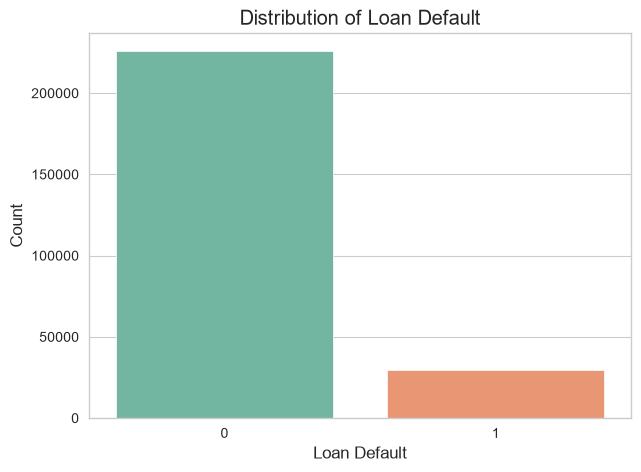

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Default",
    palette="Set2"
)

plt.title("Distribution of Loan Default")

plt.xlabel("Loan Default")

plt.ylabel("Count")

plt.show()

In [15]:
default_counts = df["Default"].value_counts()

default_percentage = (
    df["Default"].value_counts(normalize=True)*100
)

summary = pd.DataFrame({
    "Count": default_counts,
    "Percentage": default_percentage.round(2)
})

summary

,Count,Percentage
Default,,
0,225694,88.39
1,29653,11.61


## Business Insight

The dataset exhibits an **imbalanced target distribution**, with significantly fewer default cases compared to non-default cases.

This imbalance is common in credit risk datasets because most borrowers successfully repay their loans.

During model development, we will consider techniques such as:

- Stratified Train-Test Split
- Class Weight Adjustment
- SMOTE (if required)
- Evaluation metrics beyond Accuracy (Precision, Recall, F1-score, ROC-AUC)

# 🔢 Separating Numerical and Categorical Features

For effective analysis, we first separate numerical and categorical variables.

This allows us to apply appropriate visualization and preprocessing techniques to each group.

In [16]:
numerical_features = df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']

Categorical Features
['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


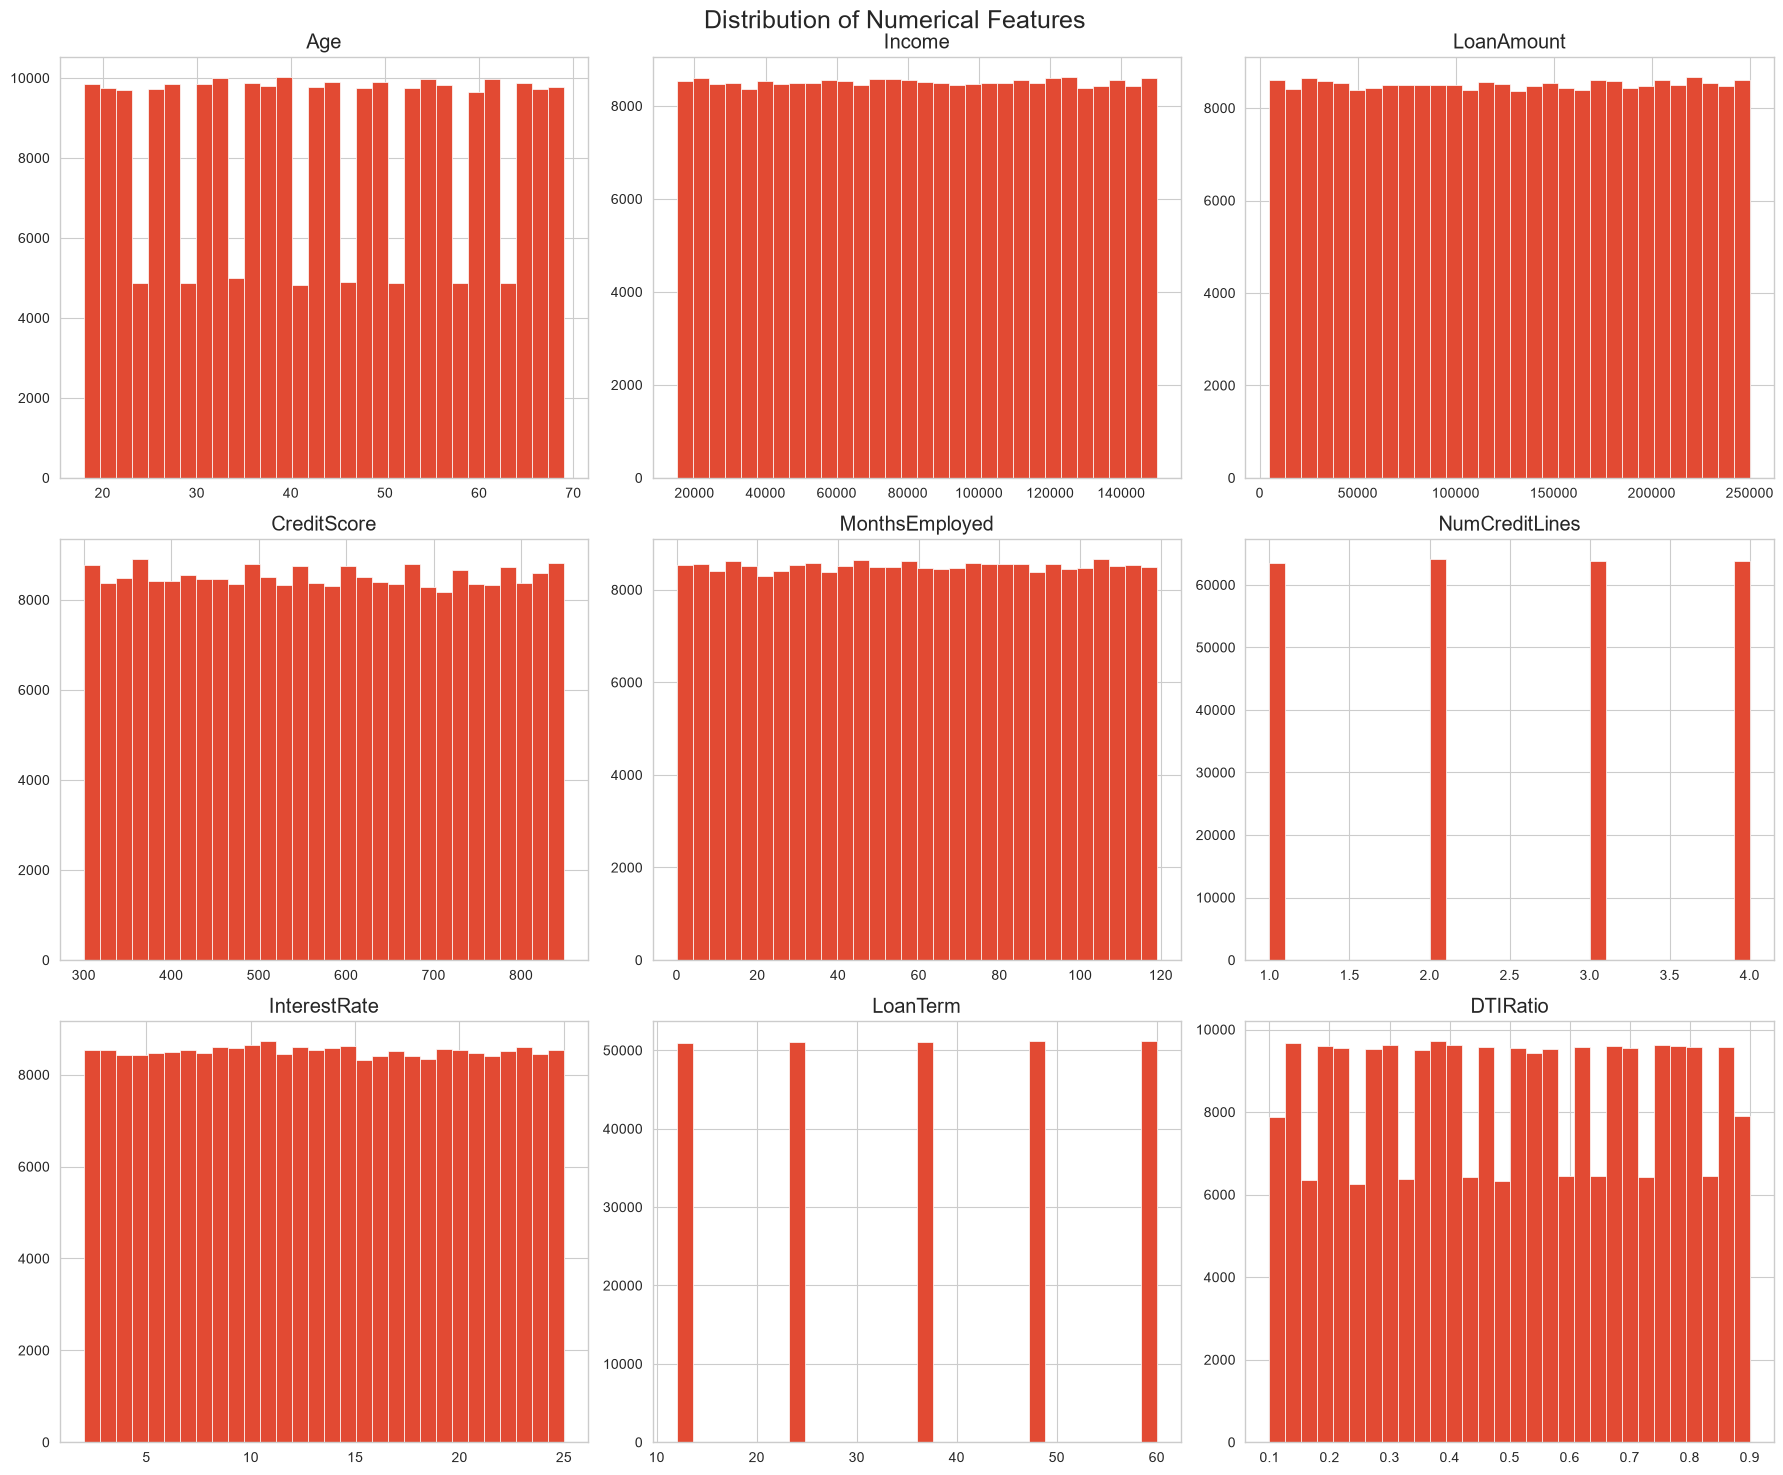

In [17]:
# Exclude LoanID and Target

num_cols = [
    col for col in numerical_features
    if col != "Default"
]

df[num_cols].hist(
    figsize=(18,15),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["Default"].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

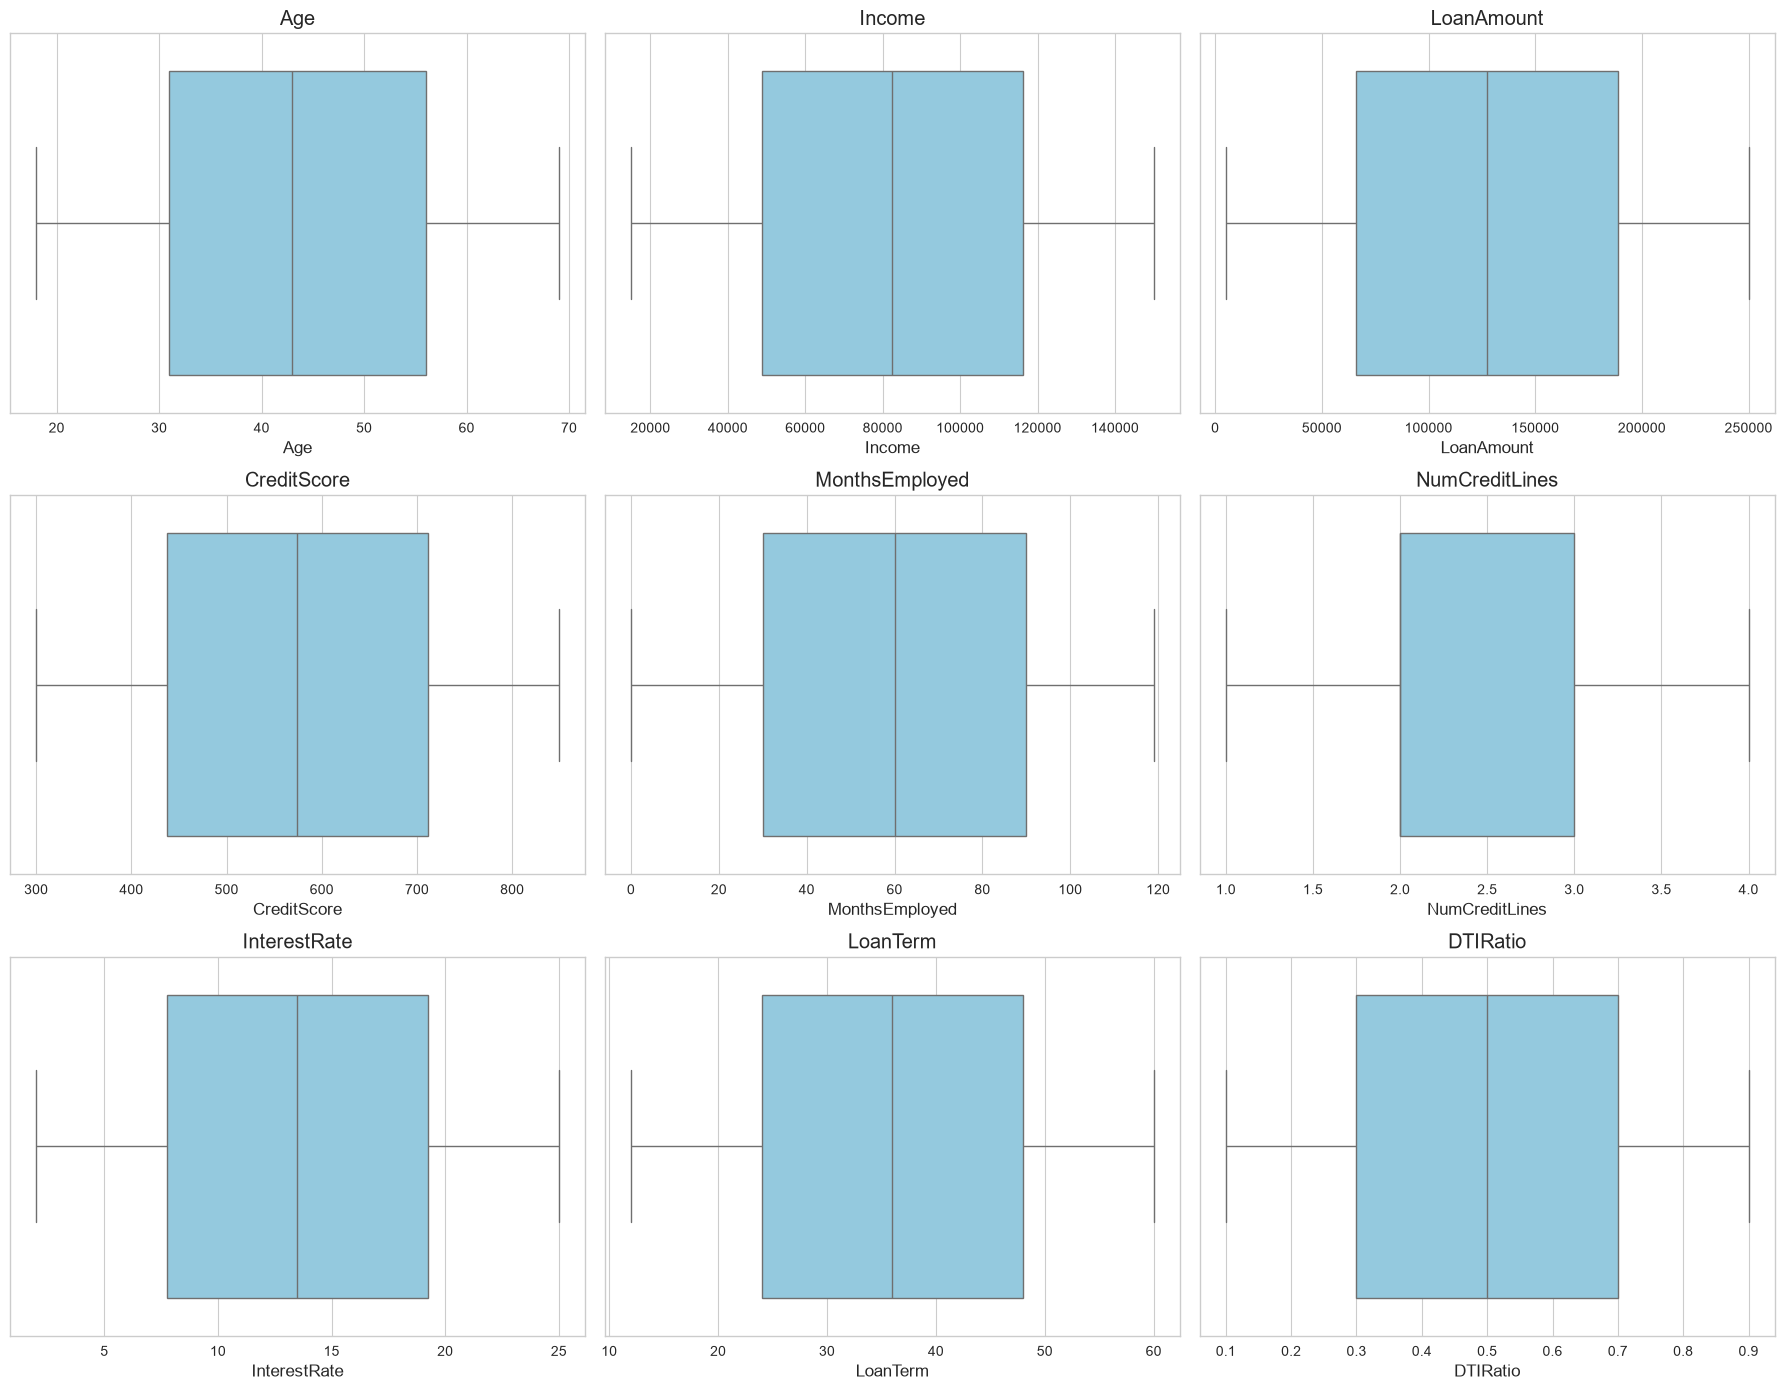

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

# 📊 Correlation Analysis

Correlation analysis measures the strength of the linear relationship between numerical variables.

This helps identify:

- Strongly correlated features
- Weak relationships
- Potential multicollinearity
- Features that may influence loan default

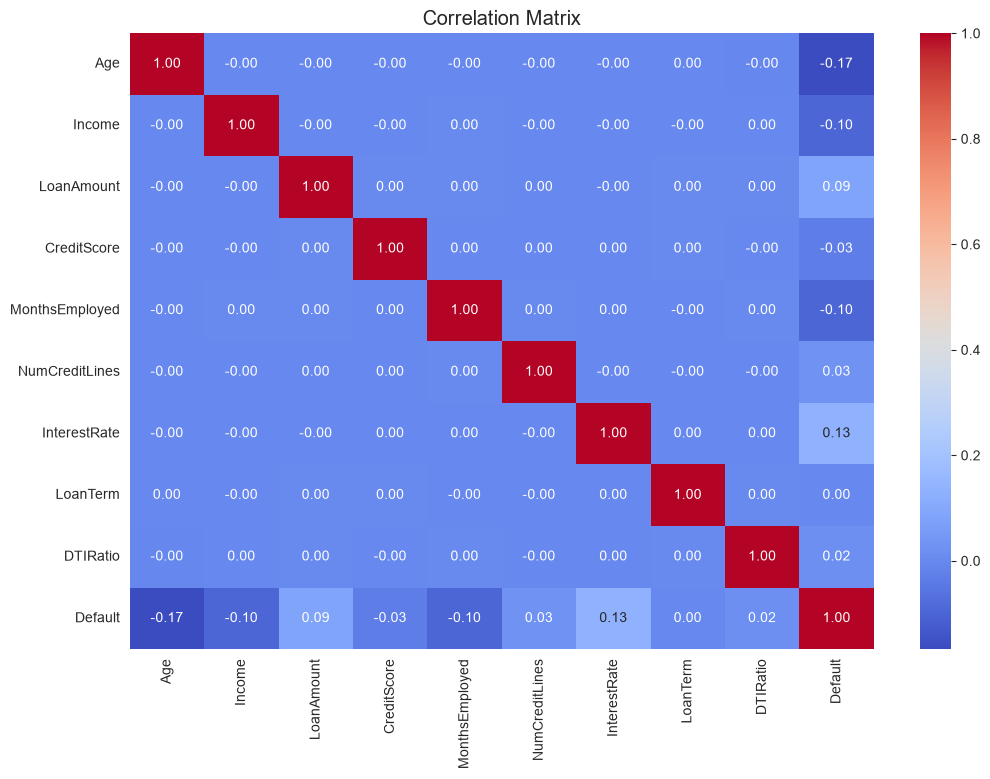

In [21]:
plt.figure(figsize=(12,8))

correlation = df[num_cols + ["Default"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# 📊 Categorical Feature Analysis

Categorical variables often capture important customer characteristics.

We analyze their distributions to understand customer demographics and loan-related information.

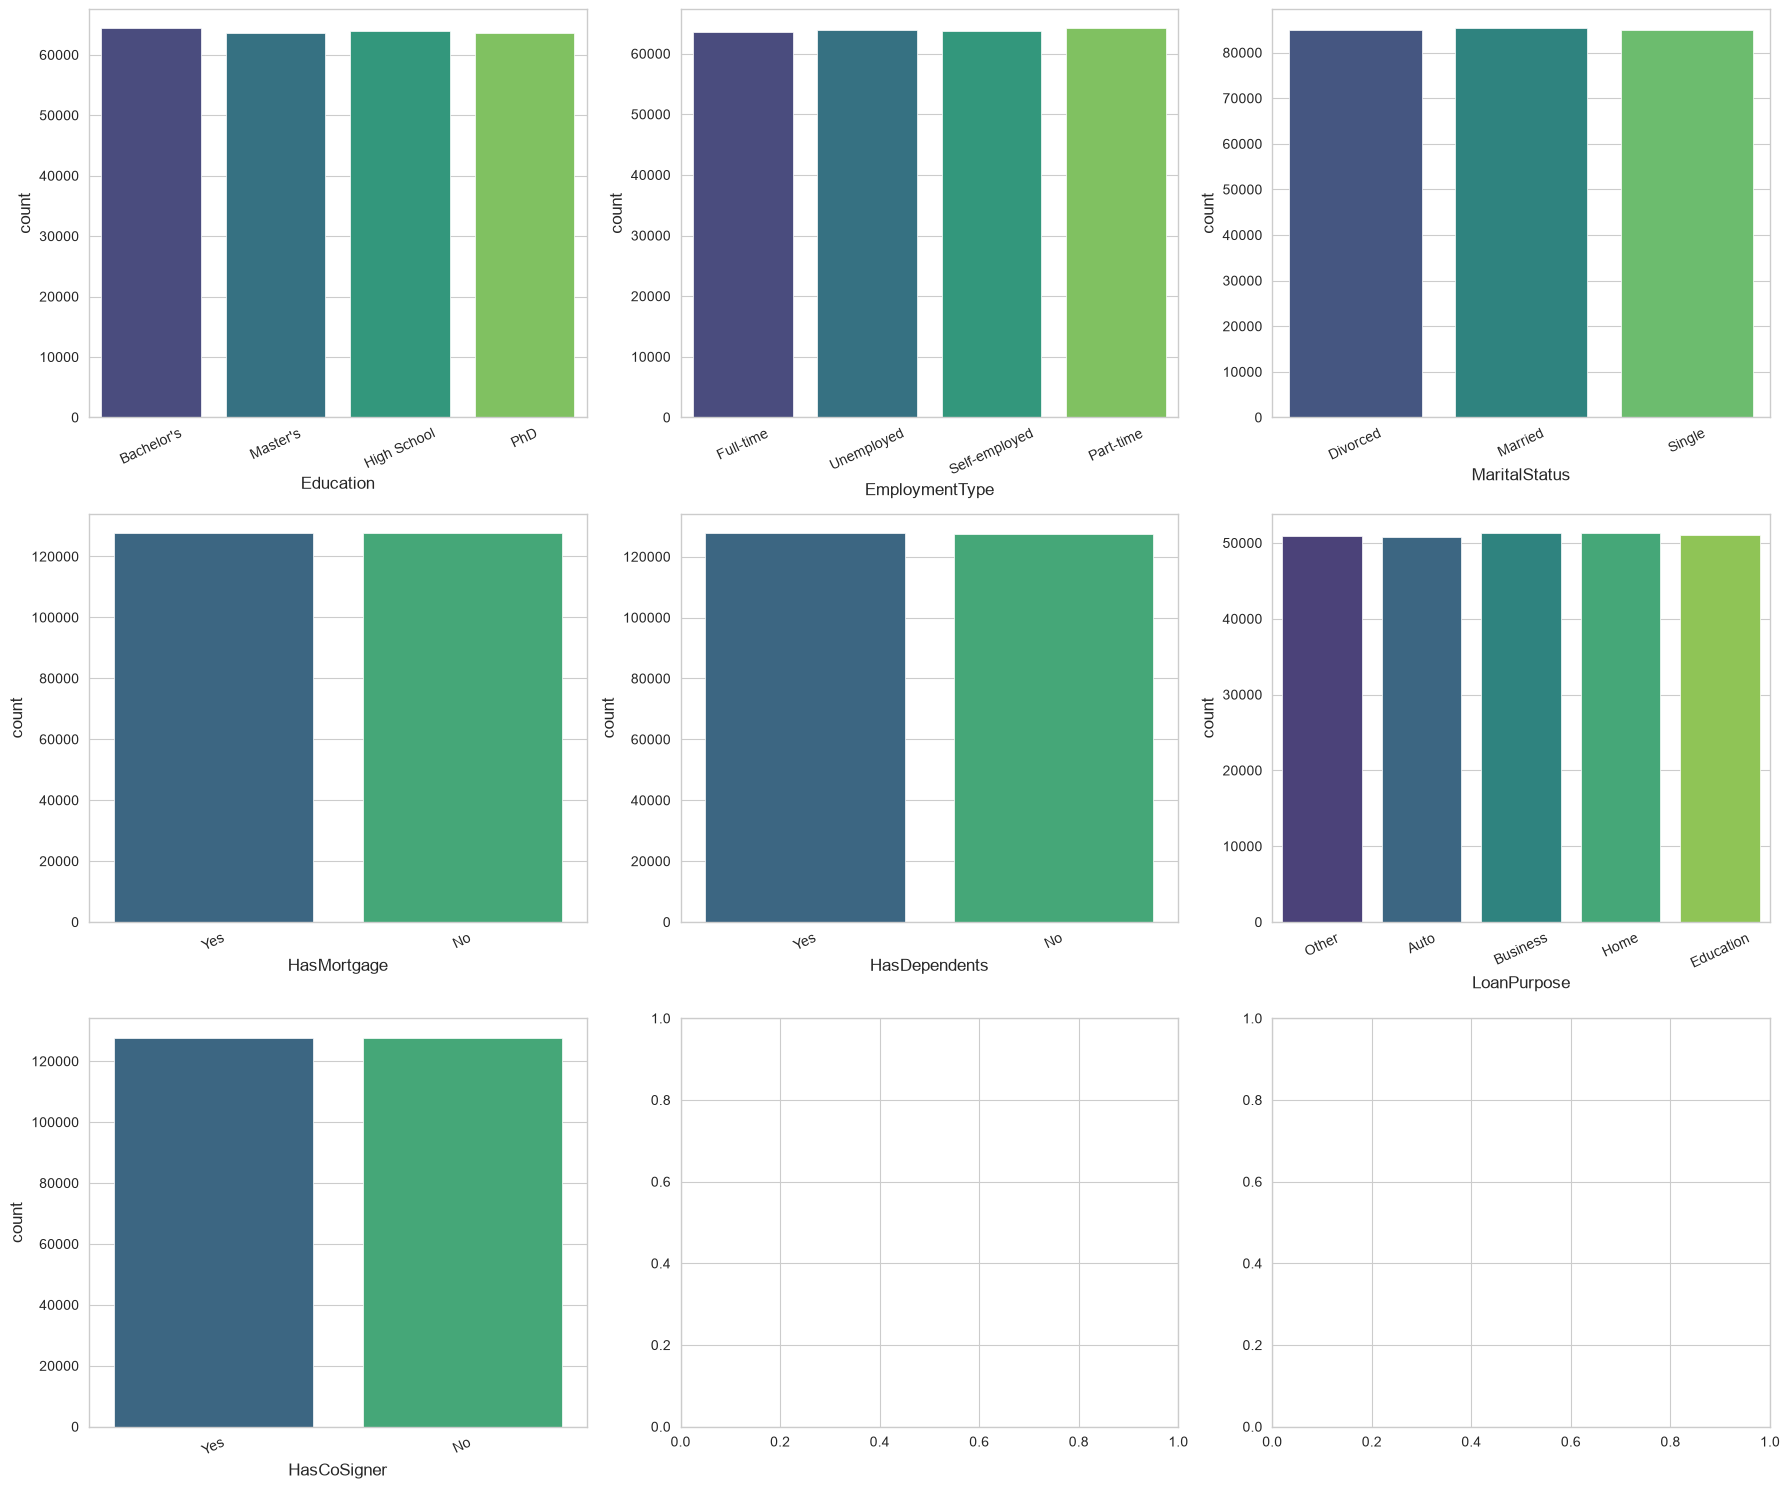

In [22]:
cat_cols = [col for col in categorical_features if col != "LoanID"]

fig, axes = plt.subplots(3,3, figsize=(18,15))

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()

plt.show()

# 📊 Default Rate by Category

Rather than only analyzing category frequencies, it is more informative to examine how loan default varies across different customer groups.

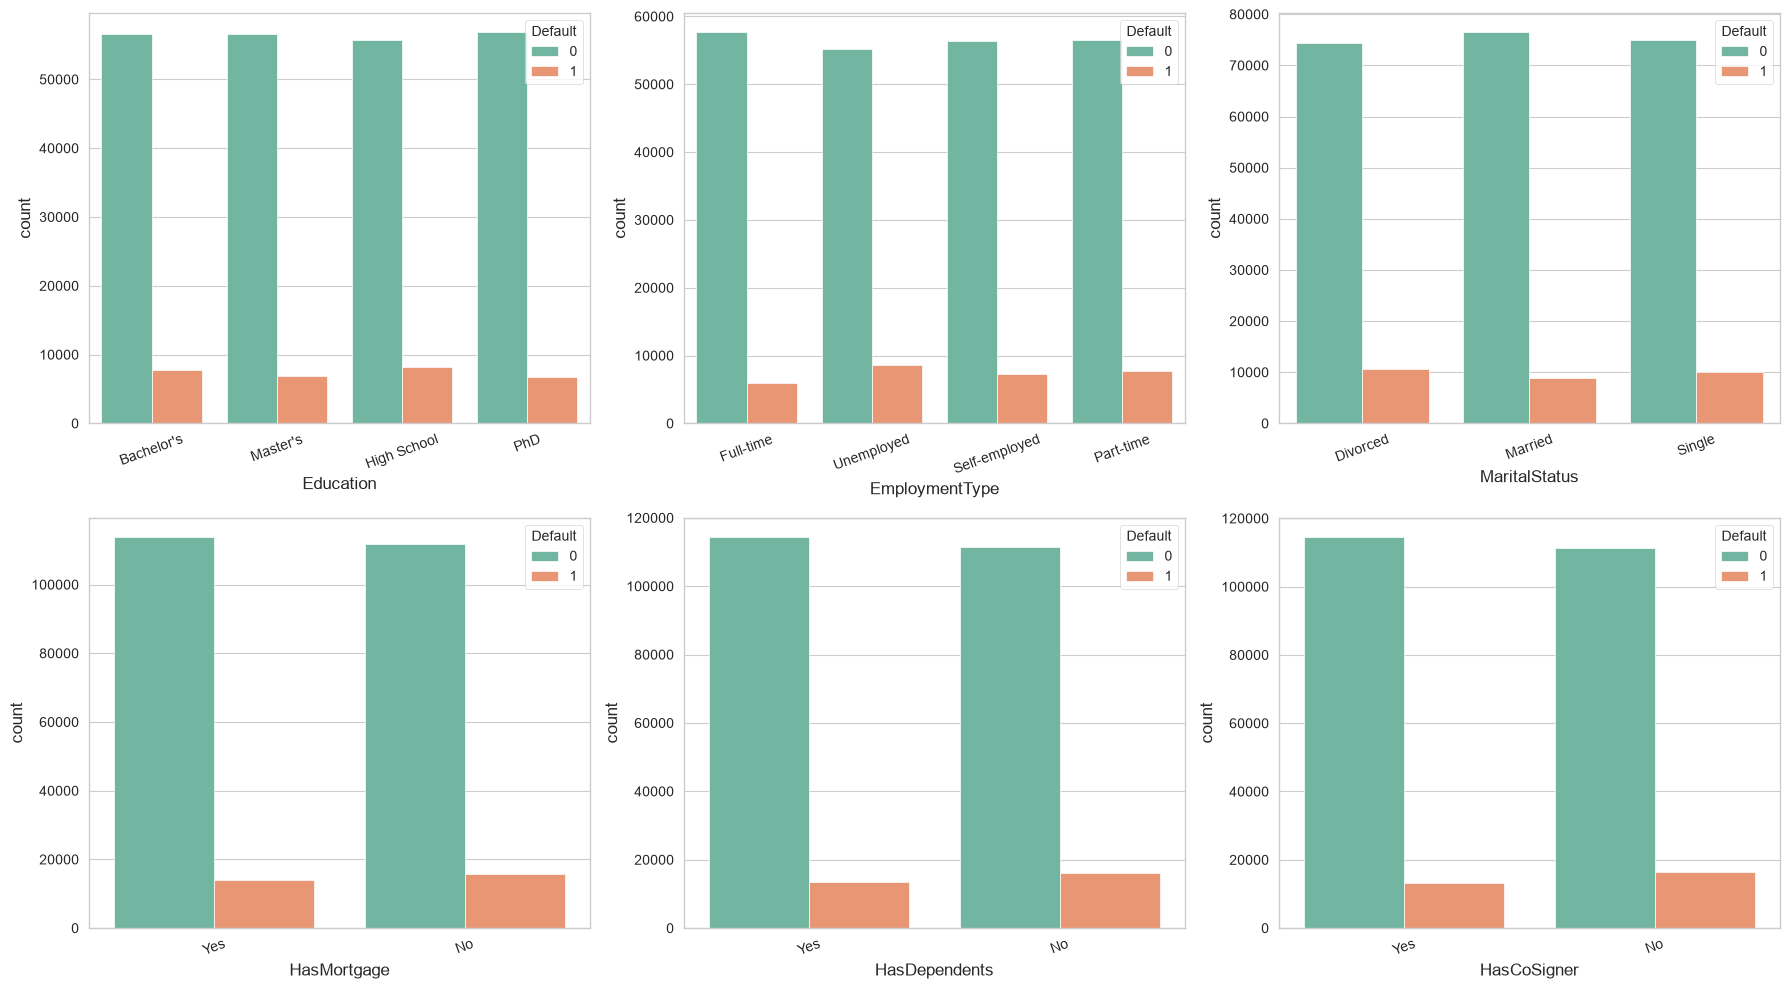

In [23]:
fig, axes = plt.subplots(2,3, figsize=(18,10))

columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "HasCoSigner"
]

axes = axes.flatten()

for i, col in enumerate(columns):

    sns.countplot(
        data=df,
        x=col,
        hue="Default",
        palette="Set2",
        ax=axes[i]
    )

    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()

plt.show()

## 🔍 Summary of EDA

- The dataset contains **255,347 loan applications** across **18 features**.
- No missing values or duplicate records were found.
- The dataset includes both numerical and categorical variables.
- The target variable (**Default**) is moderately imbalanced, with approximately **11.6%** default cases.
- The `LoanID` column is an identifier and will be removed before model training.
- Numerical features appear well distributed and free from major data quality issues.
- Categorical variables require encoding prior to machine learning.
- The dataset is well suited for supervised binary classification.

# 🚀 Preprocessing Roadmap

Based on the EDA findings, the next notebook will focus on preparing the dataset for machine learning.

The preprocessing steps will include:

- Removing unnecessary columns
- Encoding categorical variables
- Feature engineering
- Train-Test Split
- Feature Scaling
- Preparing data for multiple machine learning algorithms